In [1]:
from matplotlib import font_manager
font_dirs = ["/content/drive/MyDrive/NU work/Font"]  # The path to the custom font file./content/Arial.ttf
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

print(font_files)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
font_manager.get_font_names()


import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['font.family'] = "sans-serif"
plt.rcParams['font.sans-serif'] = "Arial"

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] =8

[]


In [2]:
import pandas as pd
data_base = pd.read_excel('../results/processed_data and results/PROCESS_GE2000_BASE.xlsx', sheet_name=None)


data_harvested_area = data_base['harvested area']
data_planted_area = data_base['planted area']
data_production = data_base['production']
data_census_irrigated_harvested = data_base['census irrigated harvested']
data_census_overall_harvested = data_base['census overall harvested']
data_water_applied = data_base['water applied']



/var/folders/p6/gfs0tclx54s6gmp1xr1zs4780000gr/T/ipykernel_6771/2526975879.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(planted_area.index))


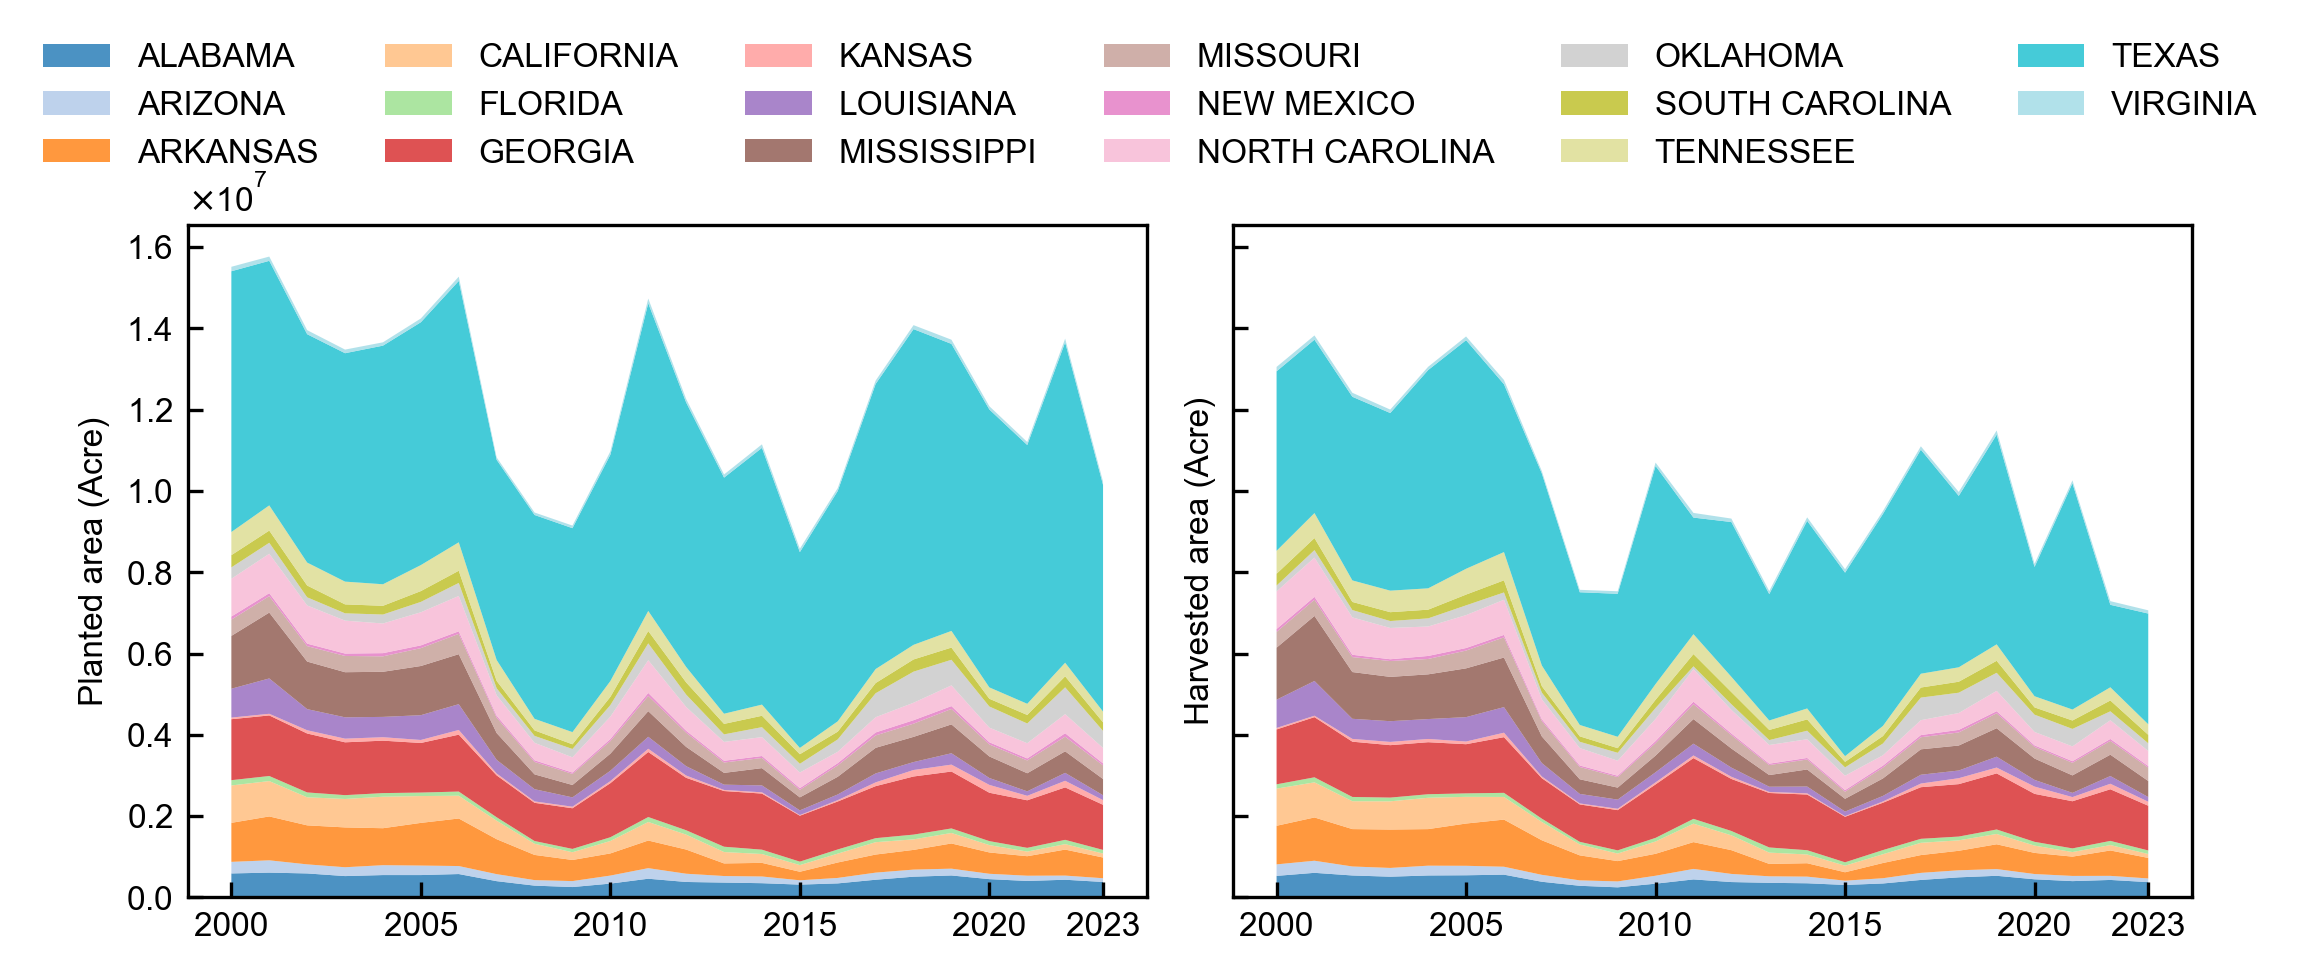

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

planted_area = data_planted_area.set_index('Category')
harvested_area = data_harvested_area.set_index('Category')


planted_area.columns = pd.to_numeric(planted_area.columns)
harvested_area.columns = pd.to_numeric(harvested_area.columns)


colors = plt.cm.get_cmap('tab20', len(planted_area.index))

fig, axs = plt.subplots(1, 2, figsize=(7.2, 2.8),
                        facecolor='white',
                        edgecolor='white',
                        frameon=False,
                        sharex=True,
                        sharey=True)

axs[0].stackplot(planted_area.columns, planted_area.values, labels=planted_area.index, colors=colors.colors, alpha=0.8)
axs[1].stackplot(harvested_area.columns, harvested_area.values, labels=harvested_area.index, colors=colors.colors, alpha=0.8)

axs[0].set_ylabel(ylabel='Planted area (Acre)', loc='center')
axs[1].set_ylabel(ylabel='Harvested area (Acre)', loc='center')

axs[0].ticklabel_format(style='sci', axis='y', scilimits=(0,1), useMathText=True)
axs[1].ticklabel_format(style='sci', axis='y', scilimits=(0,1), useMathText=True)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels,loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=6, frameon=False)
plt.subplots_adjust(bottom=0.6)

x_ticks = np.arange(start=2000, stop=2023 + 1, step=5)  # +1 to include the last value
x_ticks = np.append(x_ticks, 2023)

plt.xticks(ticks=x_ticks)

plt.tight_layout()
plt.savefig('../outputs/water/figure_planted_harvest.tiff',dpi=300, bbox_inches='tight')
plt.show()





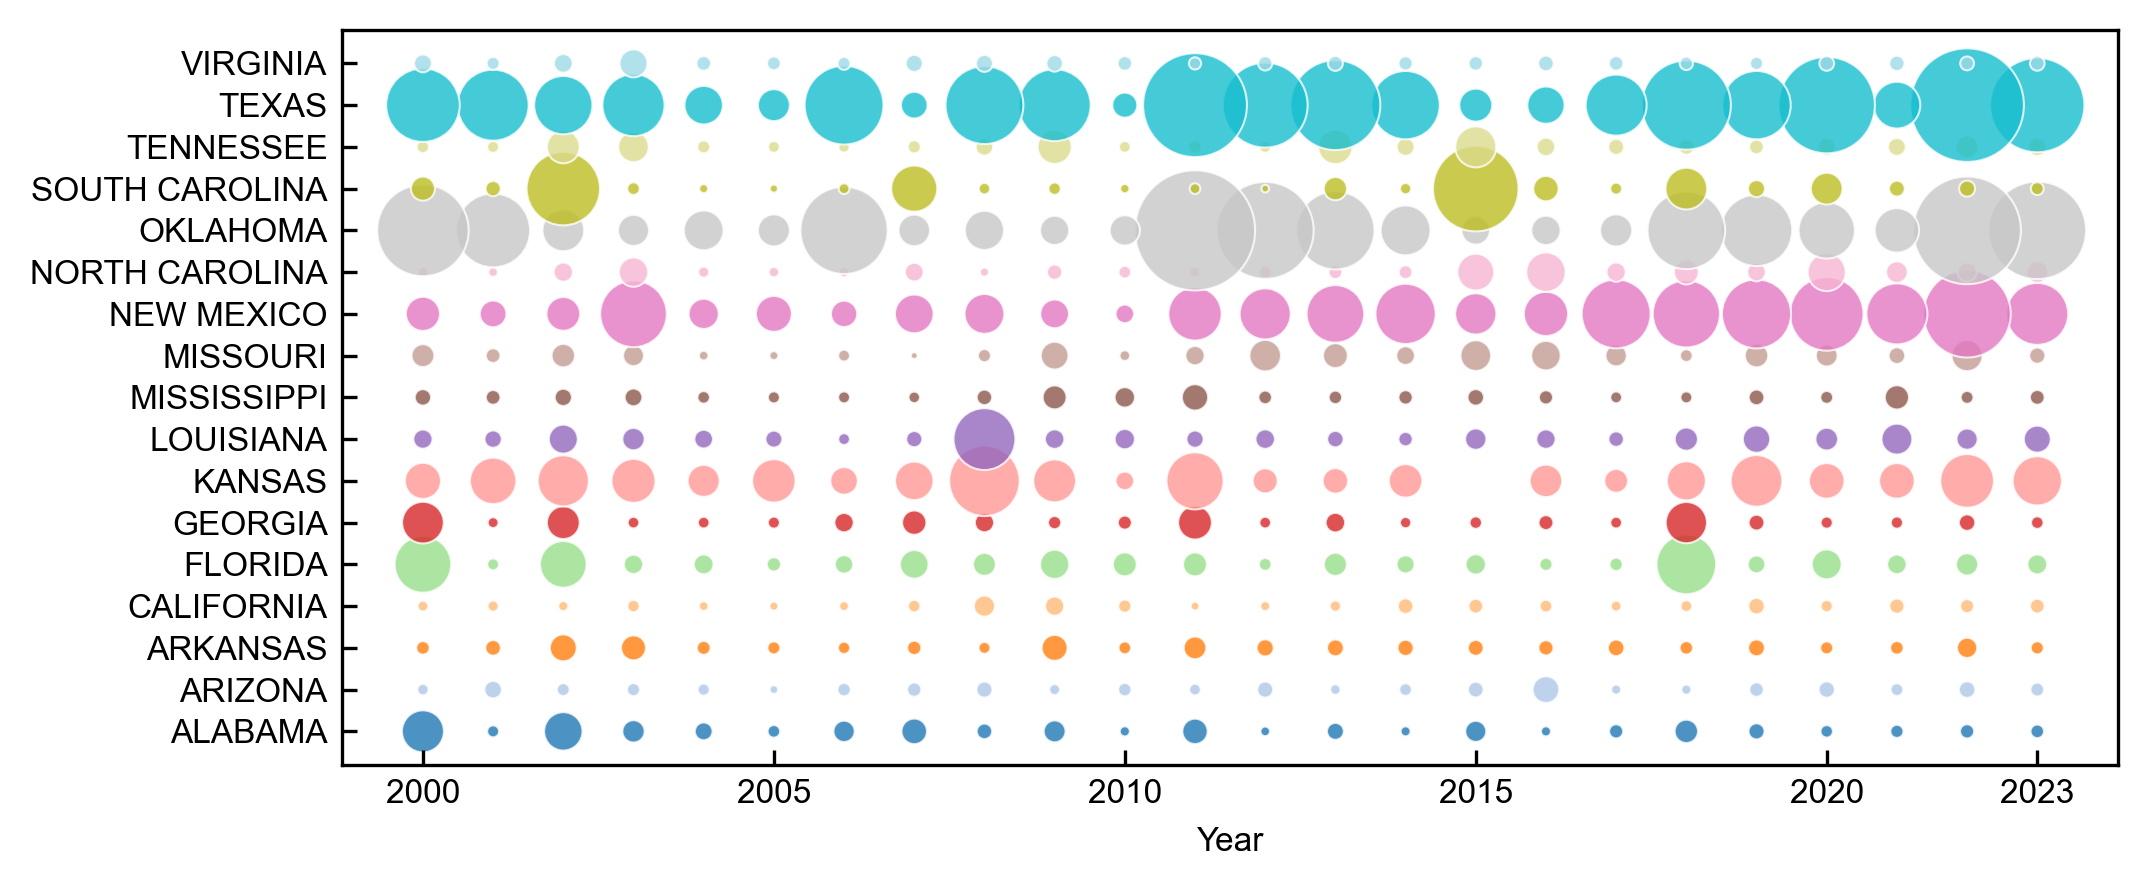

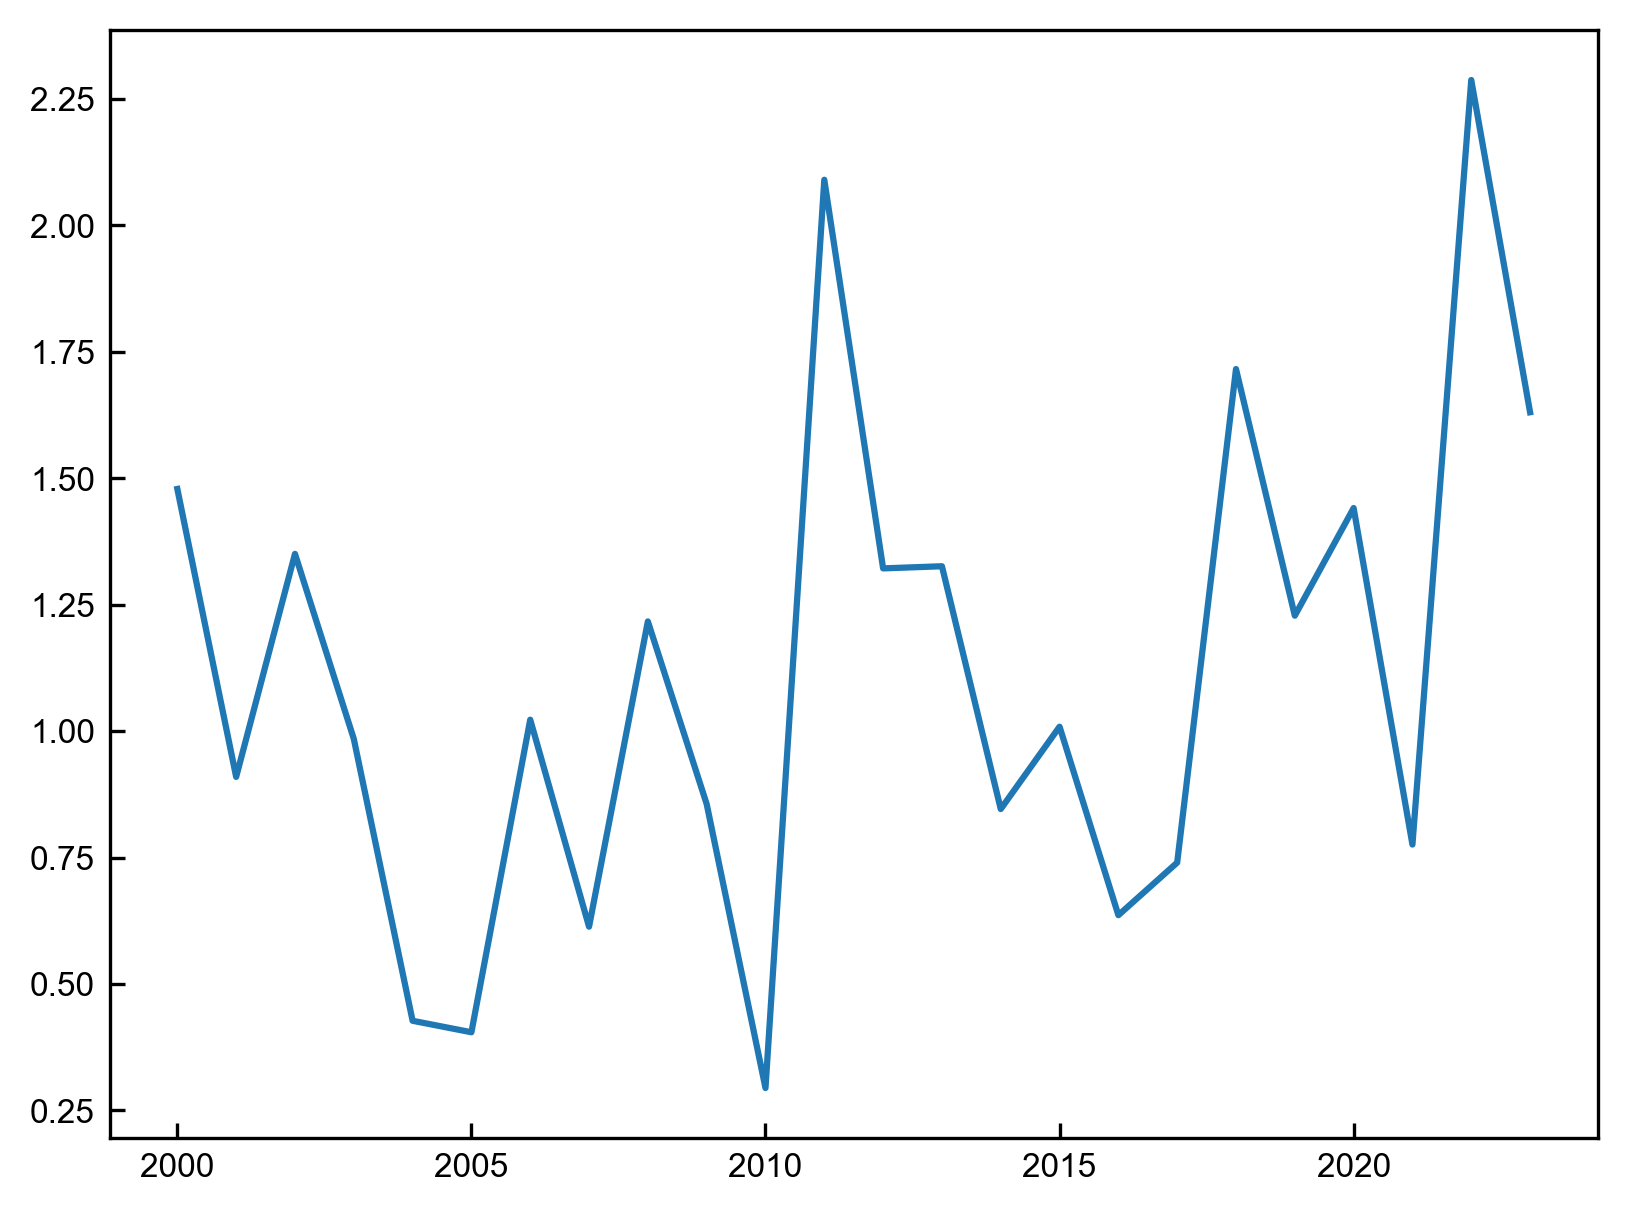

In [4]:

abandonment_rate = 1-(data_harvested_area.set_index('Category')/data_planted_area.set_index('Category'))
abandonment_rate.columns = pd.to_numeric(abandonment_rate.columns)

abandonment_rate.to_excel('../results/processed_data and results/abandonment_rate.xlsx')


import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


df = abandonment_rate.stack().reset_index()
df.columns = ['State', 'Year', 'Abandonment Rate']

states = df['State'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(states)))

color_map = dict(zip(states, colors))

df['Color'] = df['State'].map(color_map)

plt.figure(figsize=(7.2, 3),
           facecolor='white',
           edgecolor='white',
           frameon=False,)
for state in states:
    subset = df[df['State'] == state]
    plt.scatter(subset['Year'], subset['State'], s=subset['Abandonment Rate']*1000, alpha=0.8, c=subset['Color'], label=state, edgecolors='w', linewidth=0.5)

x_ticks = np.arange(start=2000, stop=2023 + 1, step=5)  # +1 to include the last value
x_ticks = np.append(x_ticks, 2023)

plt.xticks(ticks=x_ticks)
plt.xlabel('Year')
plt.tight_layout()
plt.savefig('../outputs/water/figure_abandonment.tiff',dpi=300, bbox_inches='tight')
plt.show()

plt.plot(abandonment_rate.sum(axis=0))


<Figure size 2160x900 with 0 Axes>

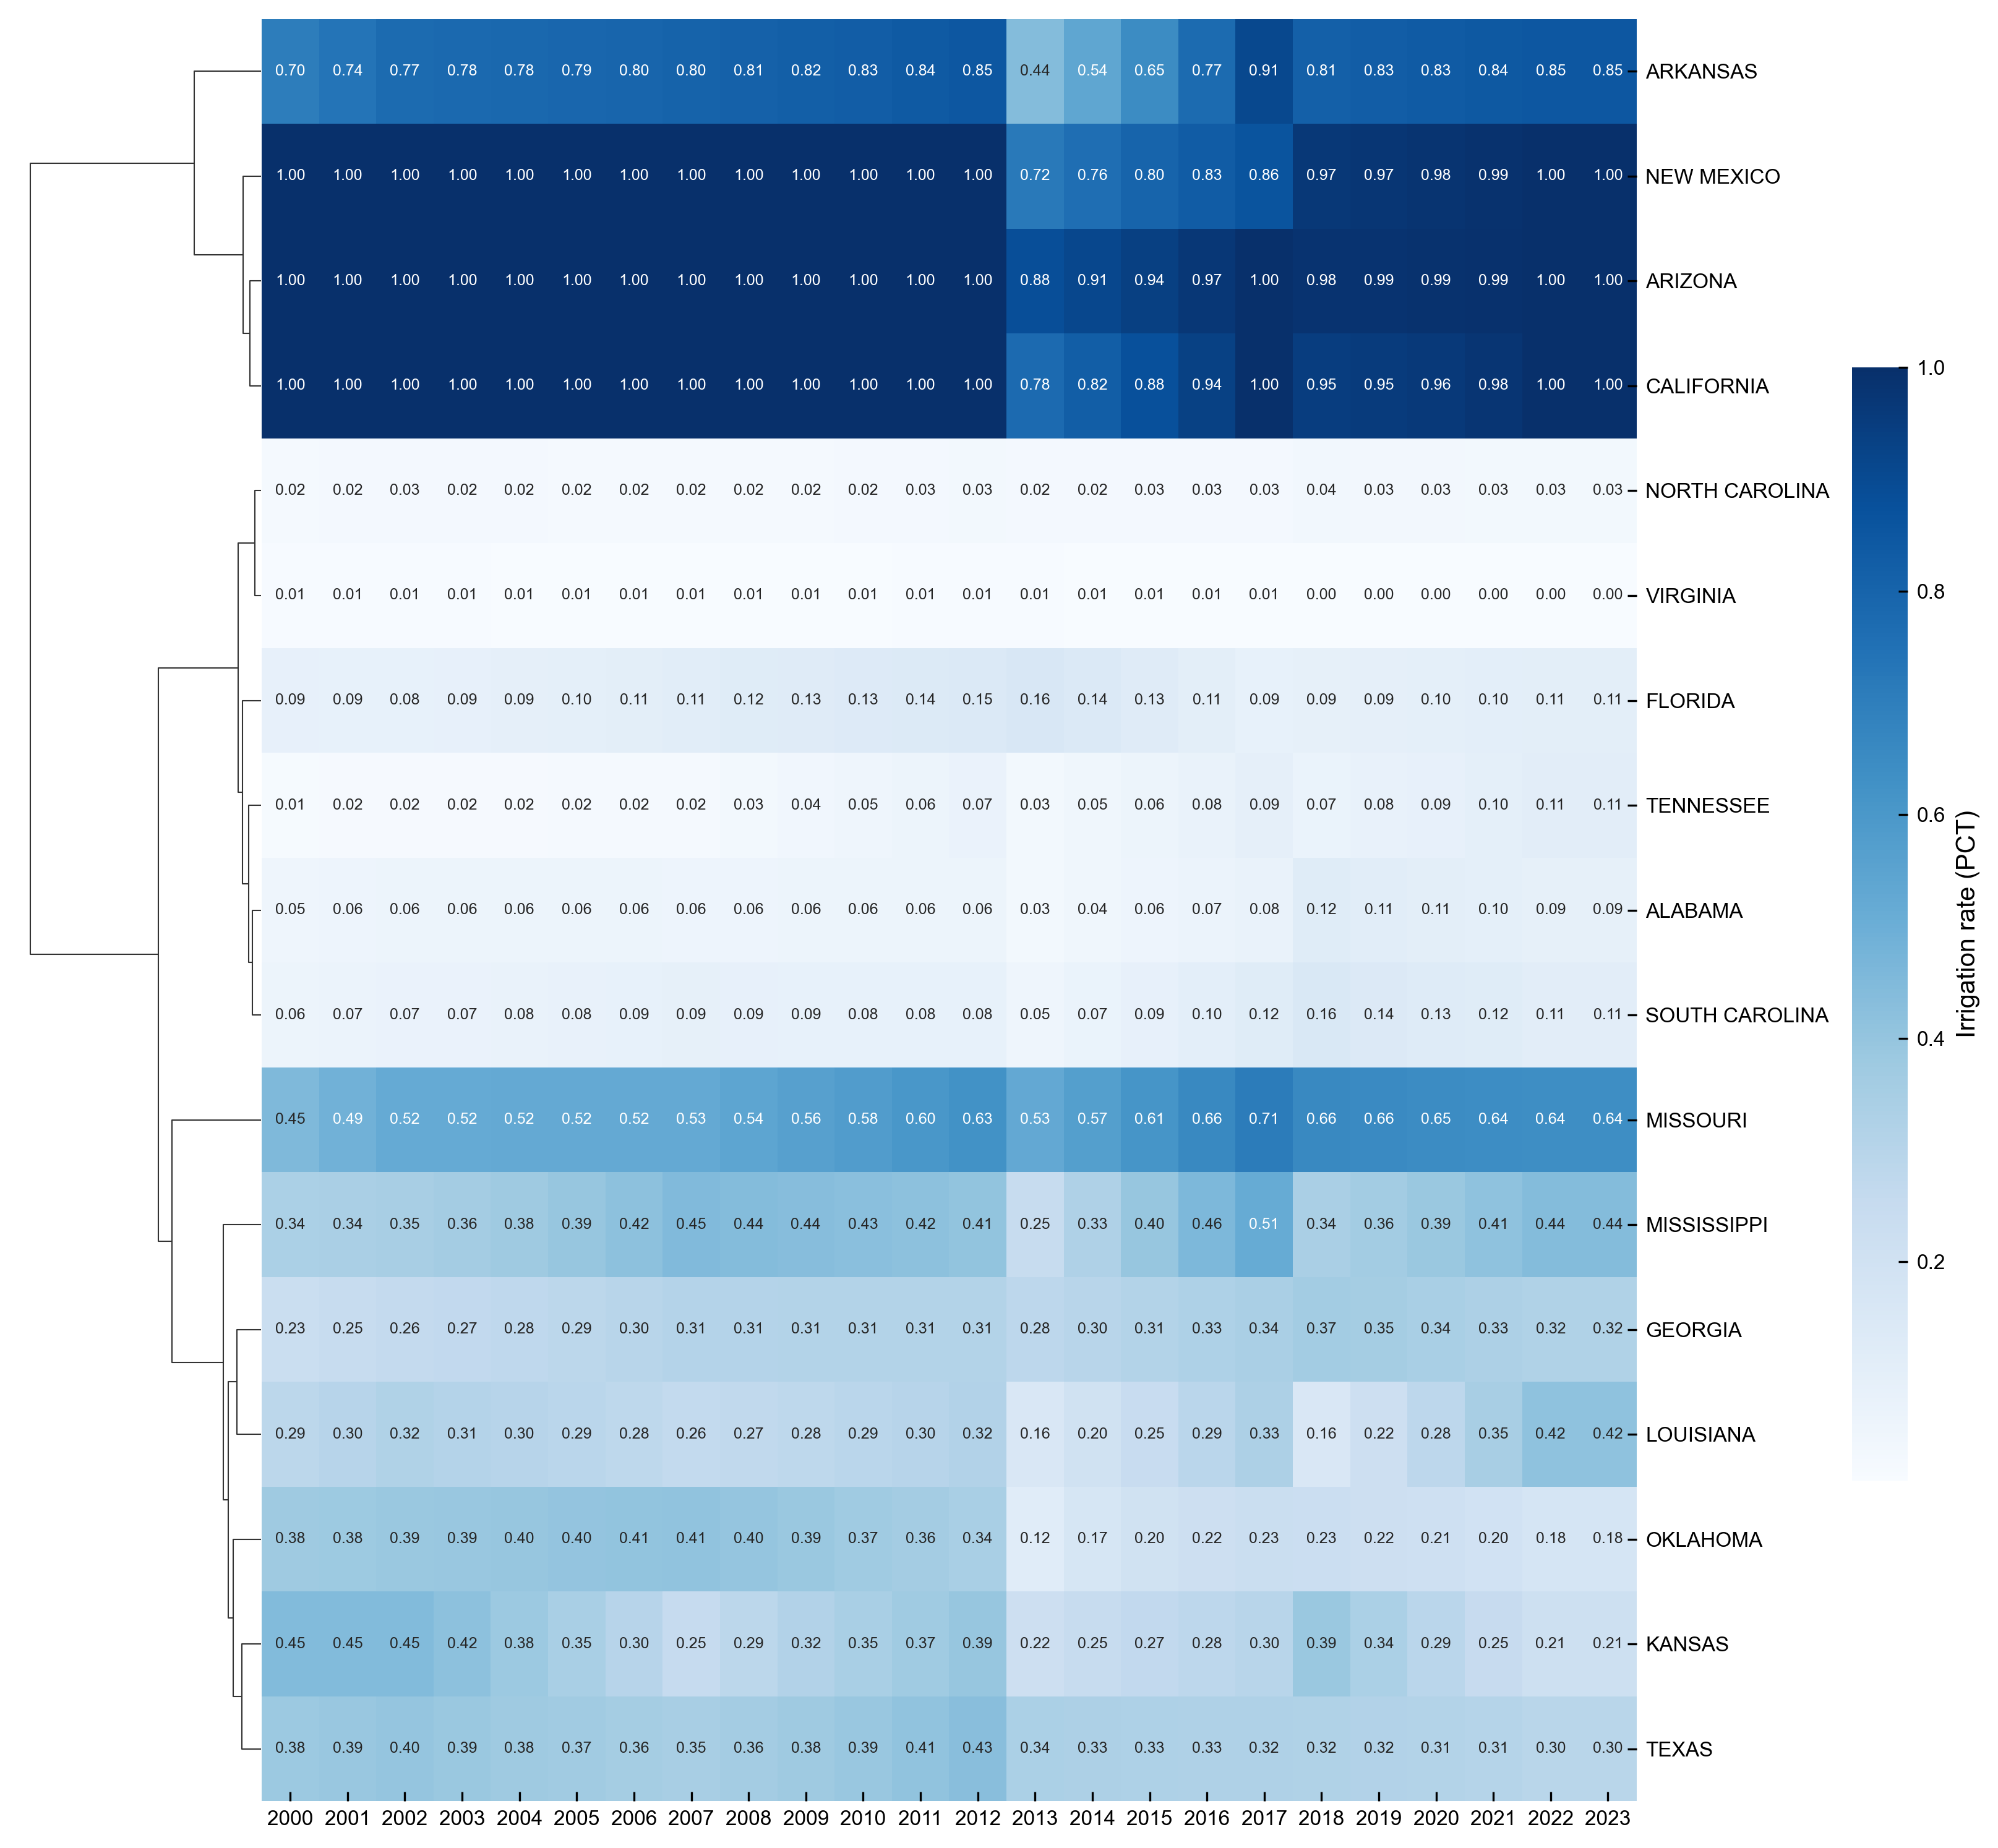

<Figure size 2160x900 with 0 Axes>

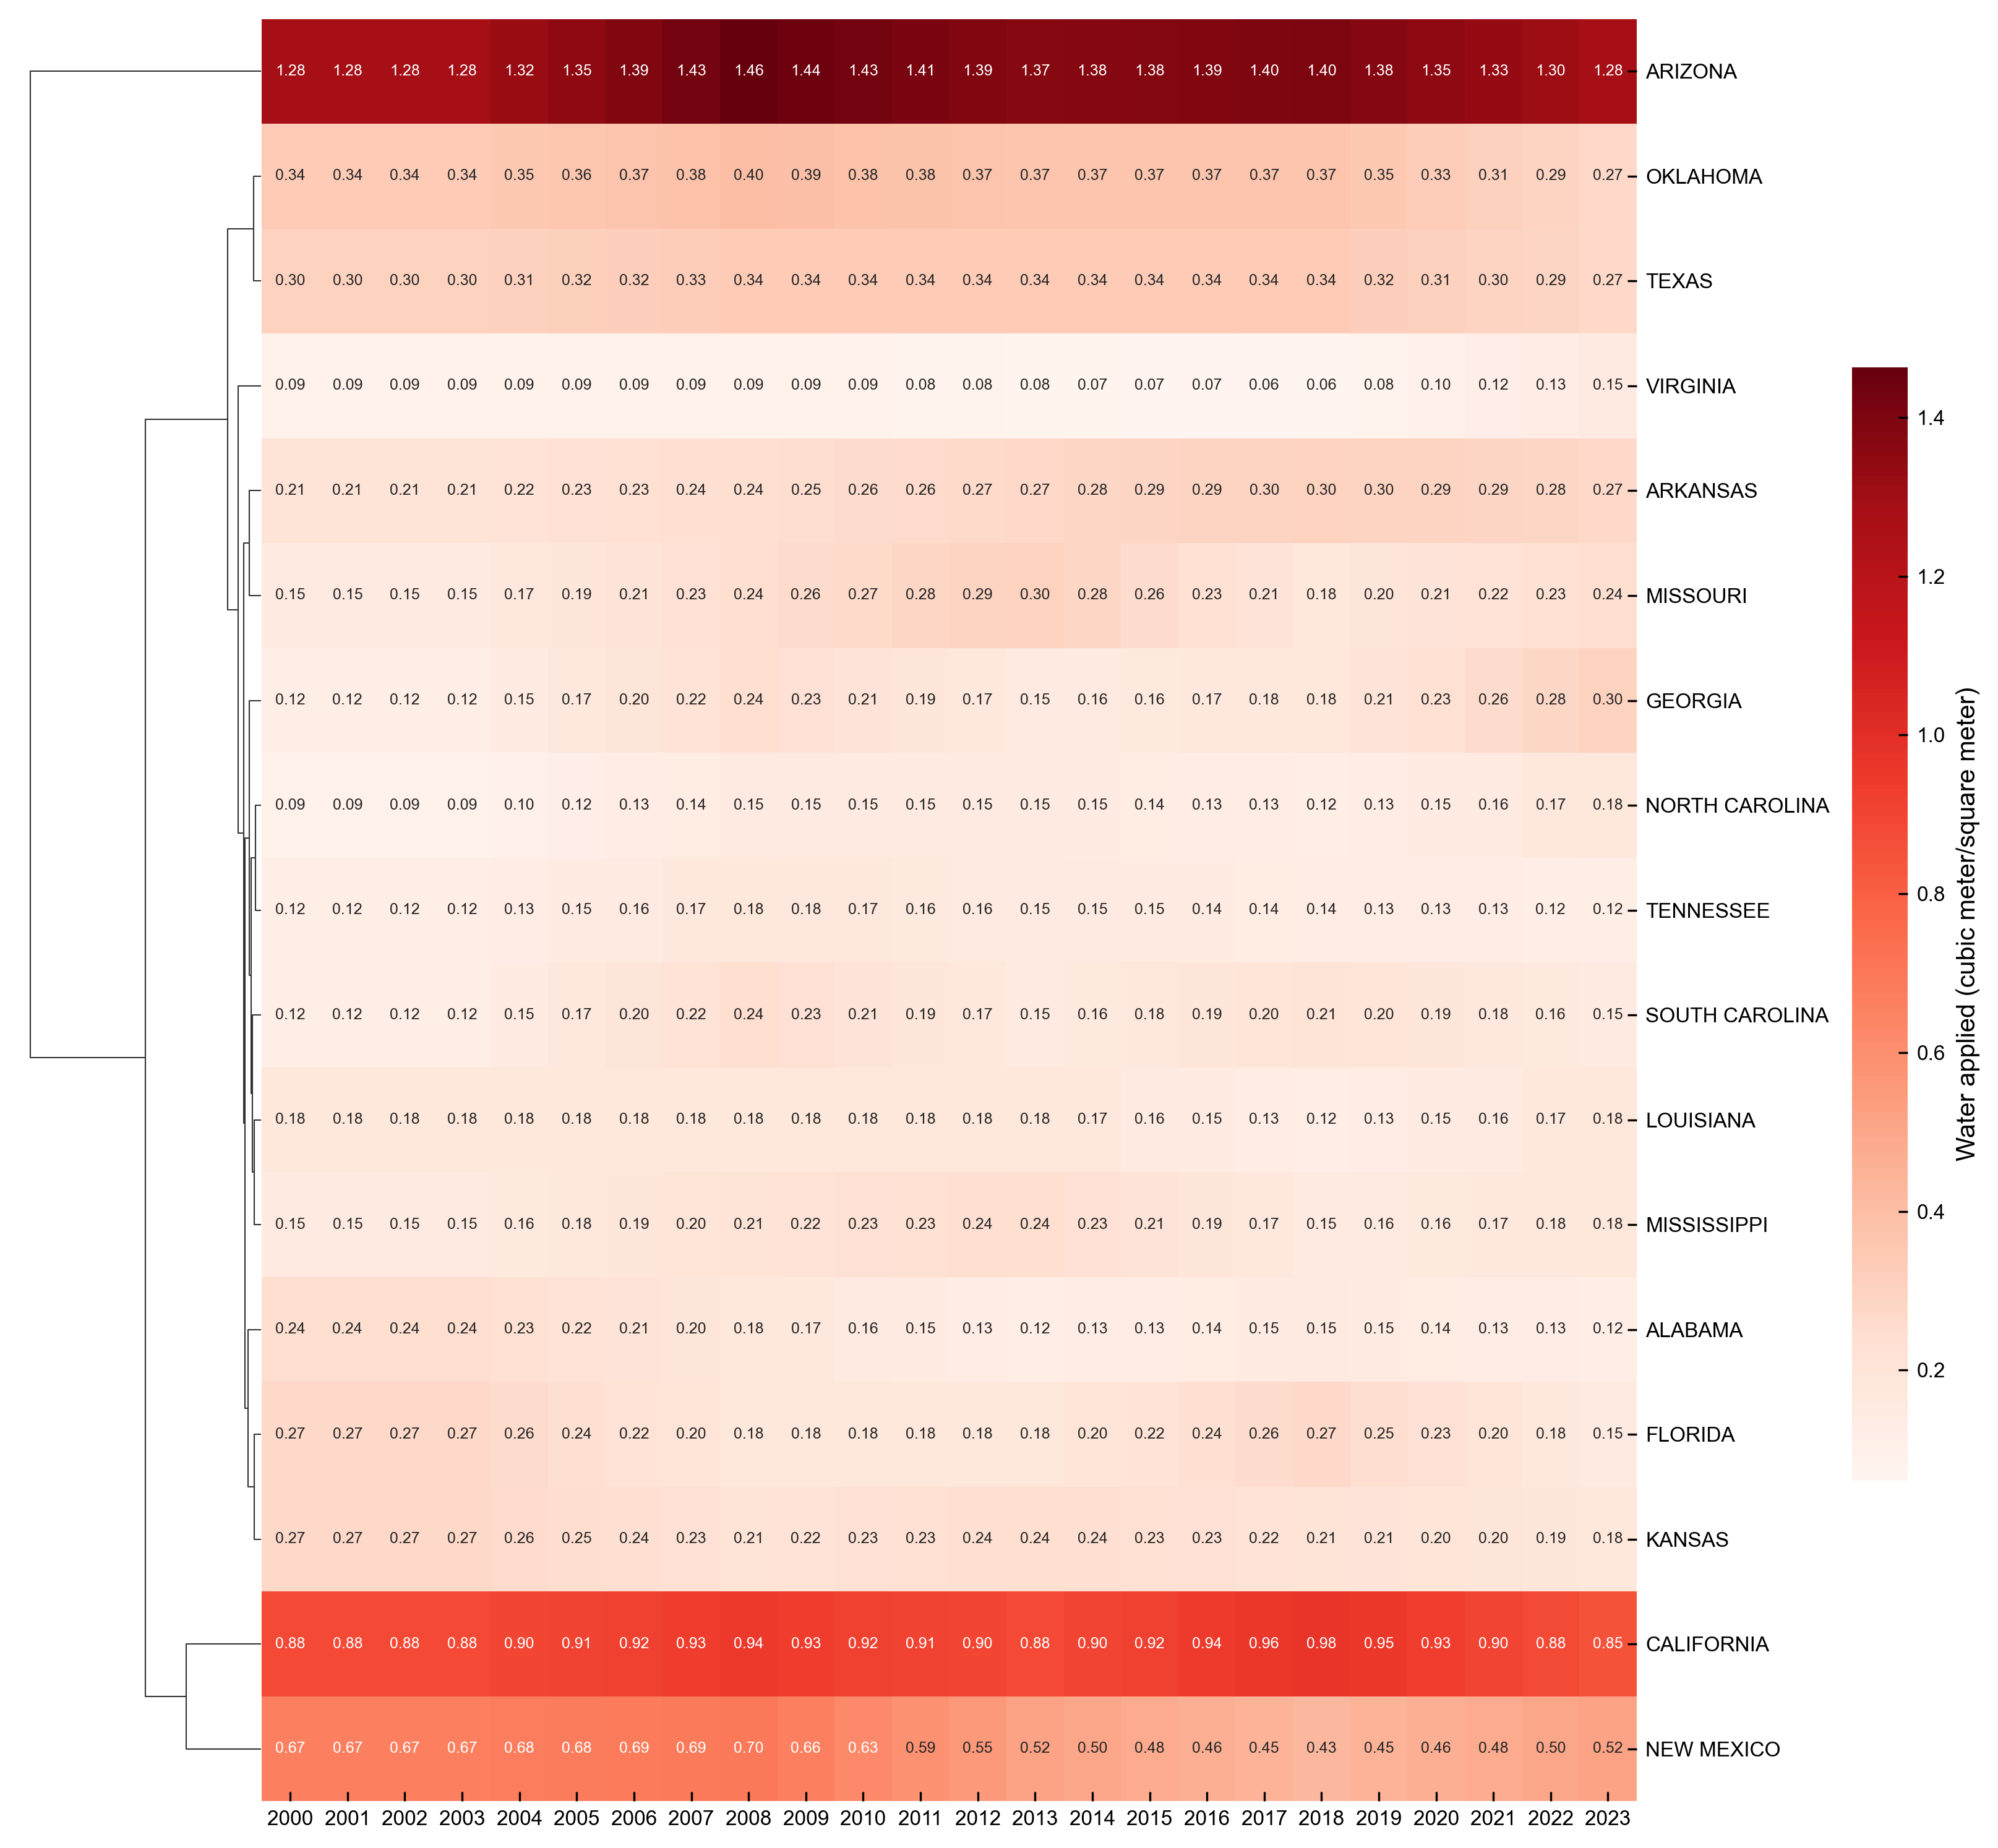

In [5]:
import seaborn as sns

irrigated_harvested = data_census_irrigated_harvested.set_index('location_desc')
overall_harvested = data_census_overall_harvested.set_index('location_desc')
irrigation_rate=(irrigated_harvested/overall_harvested).iloc[:,3:]
irrigation_rate.index.name = None

# 1 foot=0.3048 meters, so 1 acre*feet/acre = 0.3048 m2*m/m2
water_applied=data_water_applied.set_index('location_desc').iloc[:,3:]*0.3048
water_applied.index.name = None


plt.figure(figsize=(7.2, 3))
sns.clustermap(irrigation_rate, cmap='Blues', dendrogram_ratio=(.15, .0), annot=True,fmt='.2f', annot_kws={'size': 6},col_cluster=False, cbar_pos=(1, .2, .03, .6))  # `annot=True` annotates the heat values
plt.ylabel('Irrigation rate (PCT)', fontsize=10)
plt.savefig('../outputs/water/figure_irrigationrate.tiff',dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7.2, 3))
sns.clustermap(water_applied, cmap='Reds', dendrogram_ratio=(.15, .0), annot=True,fmt='.2f', annot_kws={'size': 6},col_cluster=False, cbar_pos=(1, .2, .03, .6))  # `annot=True` annotates the heat values
plt.ylabel('Water applied (cubic meter/square meter)', fontsize=10)
plt.savefig('../outputs/water/figure_waterapplied.tiff',dpi=300, bbox_inches='tight')
plt.show()


In [6]:
import matplotlib.colors as mcolors
production = data_production.set_index('Category')
production.index.name = None

planted_area = planted_area.iloc[:, ::-1]
production = production.iloc[:, ::-1]

# 1 bale= 480lb = 217.724kg
production_in_kg = production*217.724

water_applied=data_water_applied.set_index('location_desc').iloc[:,3:]

total_water_consumption=harvested_area*irrigation_rate*water_applied

# 1 acre*feet = 1233.48 m3
total_water_consumption_in_m3 = total_water_consumption*1233.48

# Figures for these two series are produced by the next cell (Nature-style
# palette); this cell only writes the underlying percentage tables, which
# 5a_Cotton_strategy.ipynb also reads.
df_transposed = production_in_kg.T
df_percent = df_transposed.div(df_transposed.sum(axis=1), axis=0)
df_percent.to_excel('../results/processed_data and results/Production_Percent.xlsx')

df_transposed = total_water_consumption_in_m3.T
df_percent = df_transposed.div(df_transposed.sum(axis=1), axis=0)
df_percent.to_excel('../results/processed_data and results/Water_Percent.xlsx')


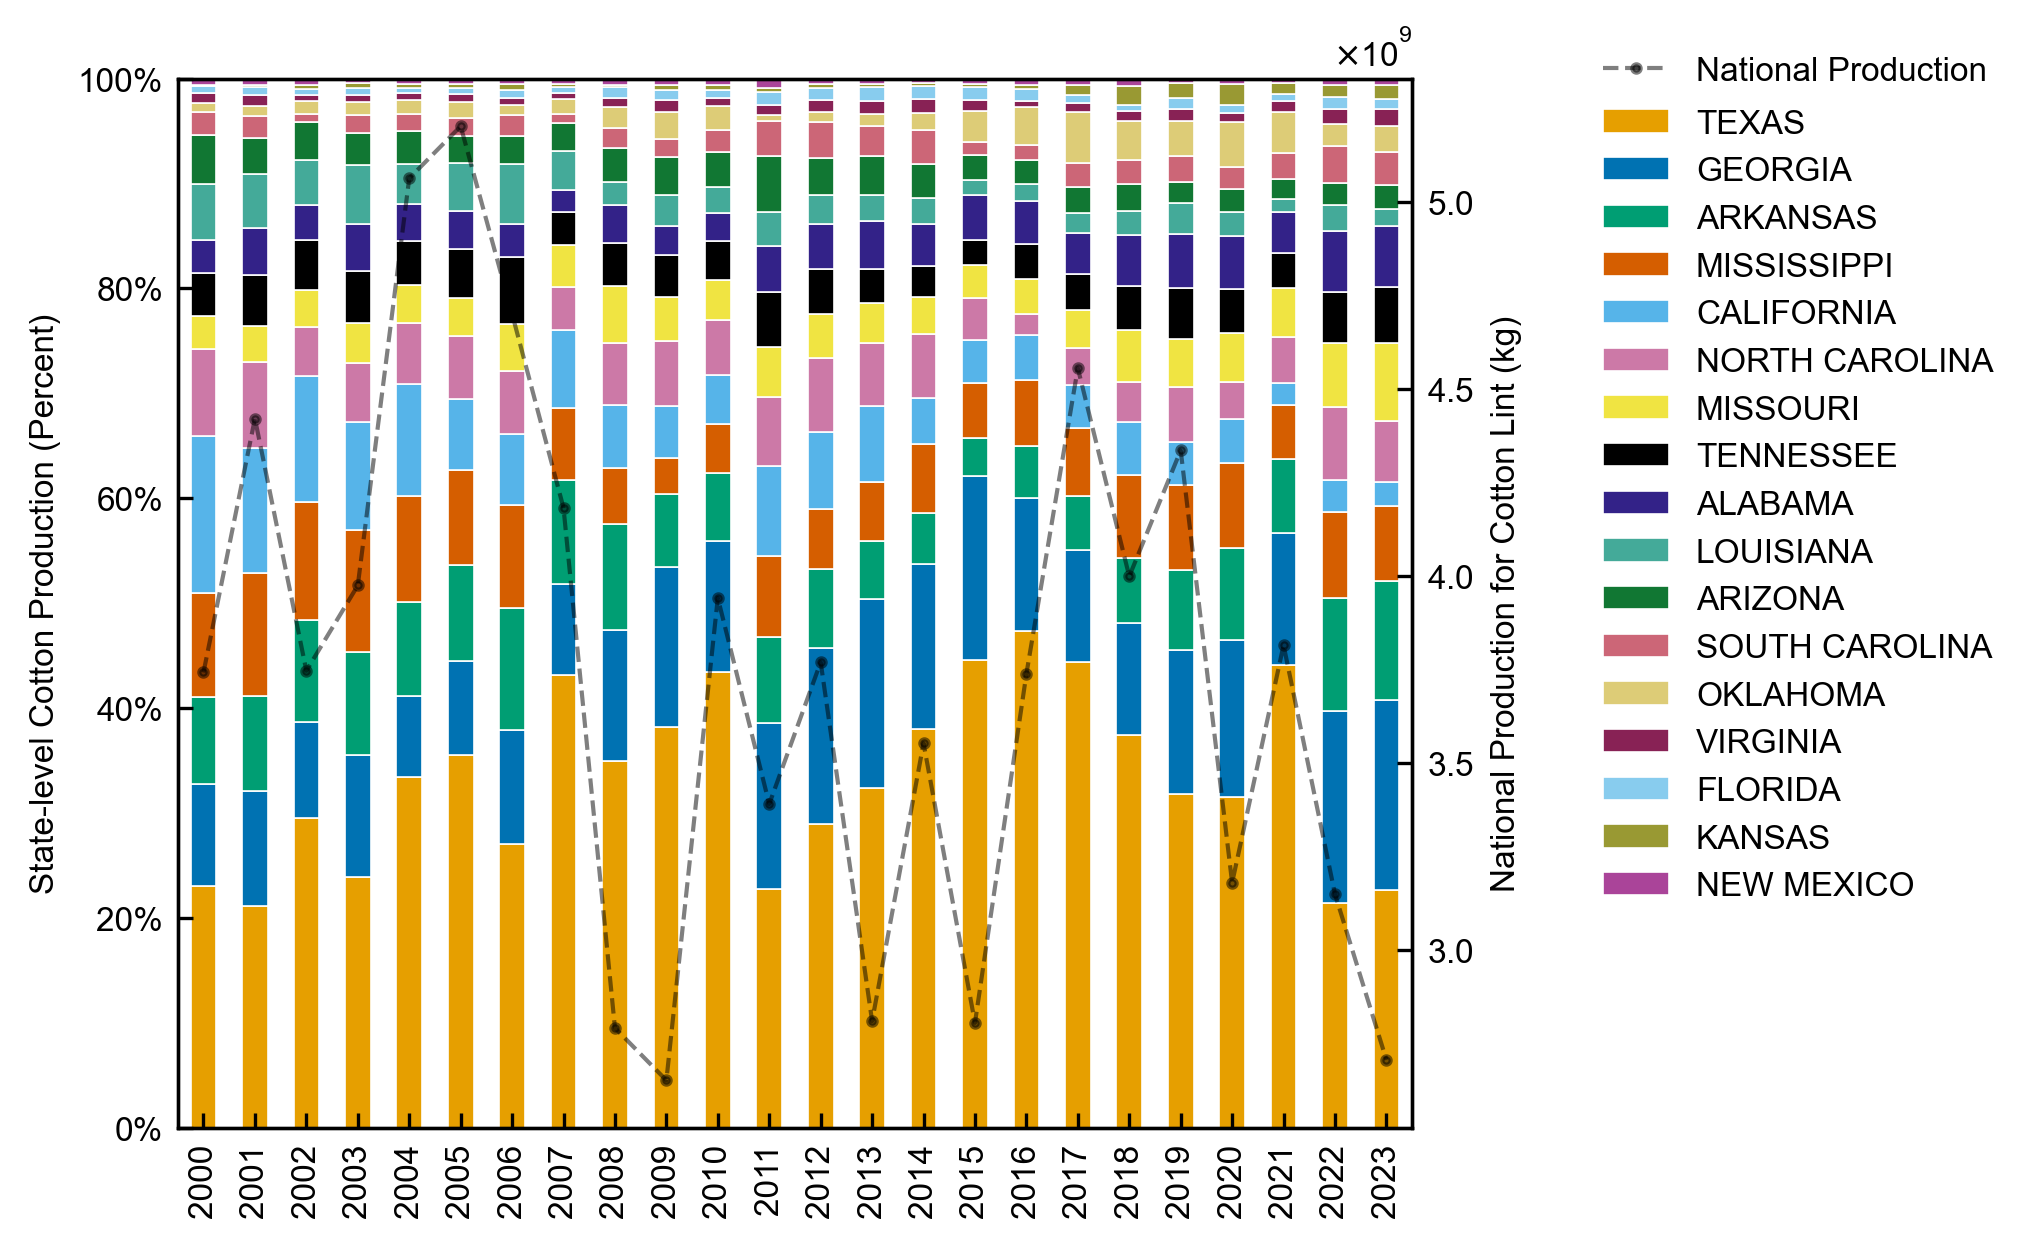

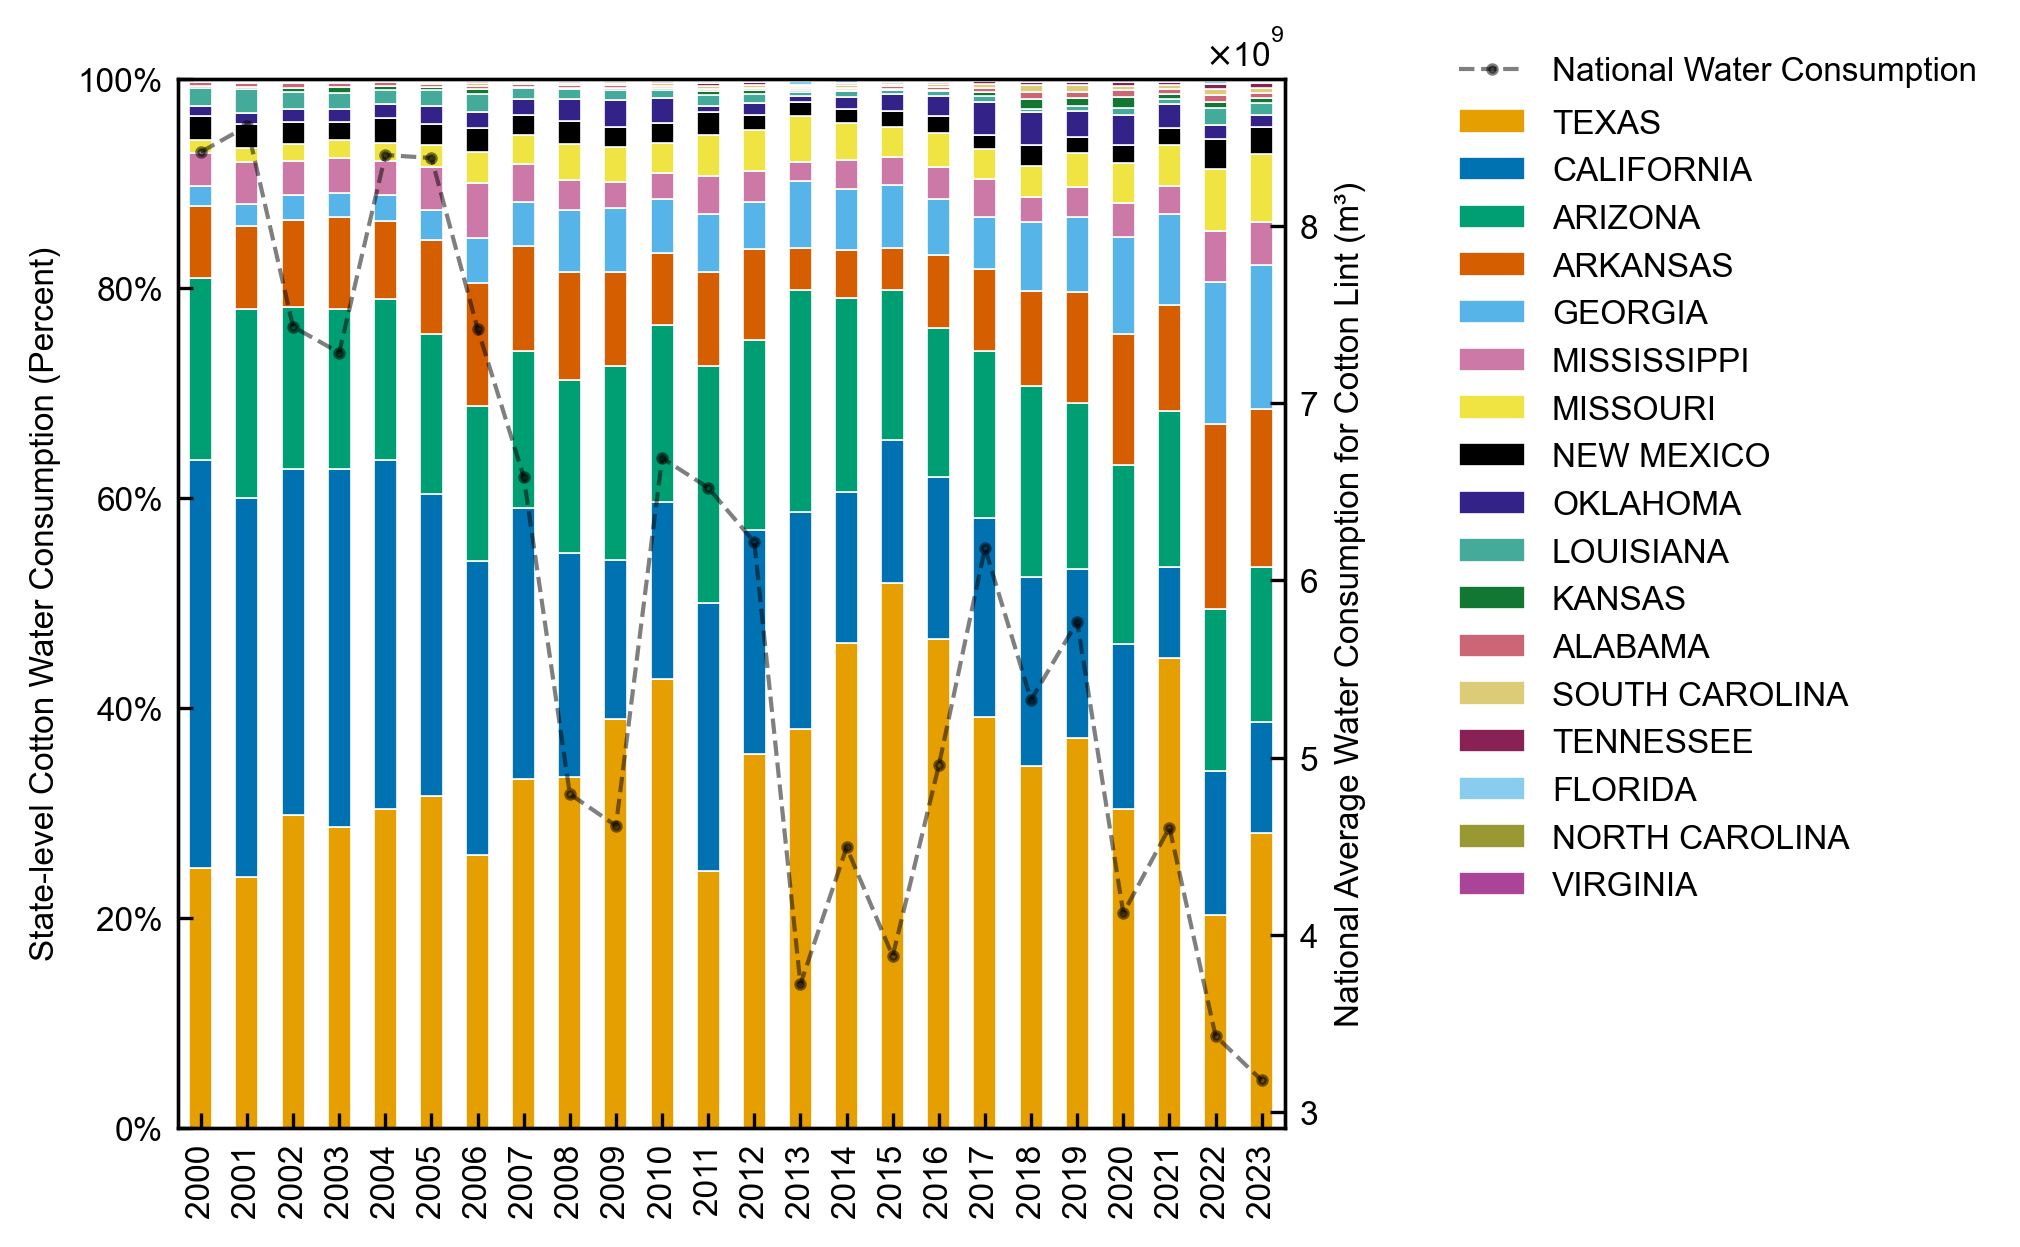

In [7]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# ── Nature-quality colorblind-safe palette (Wong 2011 + Paul Tol muted) ──
def make_nature_colors(n):
    """
    Colorblind-safe, print-friendly palette for Nature journal figures.
    Combines Wong (2011) + Paul Tol's muted set — perceptually distinct,
    no clustered blues, works in grayscale.
    """
    wong = [
        '#E69F00',  # orange
        '#0072B2',  # blue
        '#009E73',  # bluish green
        '#D55E00',  # vermillion
        '#56B4E9',  # sky blue
        '#CC79A7',  # reddish purple
        '#F0E442',  # yellow
        '#000000',  # black
    ]
    tol_muted = [
        '#332288',  # indigo
        '#44AA99',  # teal
        '#117733',  # green
        '#CC6677',  # rose
        '#DDCC77',  # sand
        '#882255',  # wine
        '#88CCEE',  # cyan
        '#999933',  # olive
        '#AA4499',  # purple
    ]
    combined = wong + tol_muted
    return combined[:n]

# ── Sort columns by mean contribution: highest contributor first (bottom of stack) ──
def sort_by_contribution(df_transposed):
    mean_share = df_transposed.div(df_transposed.sum(axis=1), axis=0).mean()
    ordered = mean_share.sort_values(ascending=False).index
    return df_transposed[ordered]

# ════════════════════════════════════════════════════════════════════════════
# Data prep
# ════════════════════════════════════════════════════════════════════════════
production = data_production.set_index('Category')
production.index.name = None

planted_area = planted_area.iloc[:, ::-1]
production   = production.iloc[:, ::-1]

production_in_kg = production * 217.724

water_applied = data_water_applied.set_index('location_desc').iloc[:, 3:]
total_water_consumption = harvested_area * irrigation_rate * water_applied
total_water_consumption_in_m3 = total_water_consumption * 1233.48

# ════════════════════════════════════════════════════════════════════════════
# Figure 1 – State-level Cotton Production (%)
# ════════════════════════════════════════════════════════════════════════════
df_transposed = sort_by_contribution(production_in_kg.T)
n_states      = df_transposed.shape[1]
colors        = make_nature_colors(n_states)

df_percent = df_transposed.div(df_transposed.sum(axis=1), axis=0)

fig, ax = plt.subplots(1, 1, figsize=(7, 4.2))
df_percent.plot(kind='bar', stacked=True, ax=ax, color=colors,
                edgecolor='white', linewidth=0.4)          # thin white borders improve readability
ax.set_ylabel('State-level Cotton Production (Percent)')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

legend = ax.legend(bbox_to_anchor=(1.13, 1), loc='upper left',
                   frameon=False, fontsize=8)
legend.set_visible(True)

ax2 = ax.twinx()
years = df_transposed.index.astype(str).tolist()
ax2.plot(years, df_transposed.sum(axis=1),
         color='k', marker='o', markersize=2,
         linestyle='--', linewidth=1,
         label='National Production', alpha=0.5)
ax2.set_ylabel('National Production for Cotton Lint (kg)')
ax2.legend(bbox_to_anchor=(1.13, 1.05), loc='upper left', frameon=False, fontsize=8)
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0, 0), useMathText=True)

plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/water/figure_production.tiff',
            dpi=300, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# Figure 2 – State-level Cotton Water Consumption (%)
# ════════════════════════════════════════════════════════════════════════════
df_transposed = sort_by_contribution(total_water_consumption_in_m3.T)
colors        = make_nature_colors(df_transposed.shape[1])

df_percent = df_transposed.div(df_transposed.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 4.2))
df_percent.plot(kind='bar', stacked=True, ax=ax, color=colors,
                edgecolor='white', linewidth=0.4)
ax.set_ylabel('State-level Cotton Water Consumption (Percent)')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

legend = ax.legend(bbox_to_anchor=(1.13, 1), loc='upper left',
                   frameon=False, fontsize=8)
legend.set_visible(True)

ax2 = ax.twinx()
years = df_transposed.index.astype(str).tolist()
ax2.plot(years, df_transposed.sum(axis=1),
         color='k', marker='o', markersize=2,
         linestyle='--', linewidth=1,
         label='National Water Consumption', alpha=0.5)
ax2.set_ylabel('National Average Water Consumption for Cotton Lint (m\u00B3)')
ax2.legend(bbox_to_anchor=(1.13, 1.05), loc='upper left', frameon=False, fontsize=8)
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0, 0), useMathText=True)

plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/water/figure_water_pct.tiff',
            dpi=300, bbox_inches='tight')
plt.show()

                       2000         2001         2002         2003  \
Category                                                             
ALABAMA          184.629103   139.290695   220.848515   143.677625   
ARIZONA         6949.019553  8279.579533  6880.818862  7614.969065   
ARKANSAS        1535.154606  1401.521459  1391.988447  1333.022182   
CALIFORNIA      4840.446149  4855.432933  4501.038780  5036.342237   
FLORIDA          366.003456   281.048985   383.415558   292.369562   
GEORGIA          354.259620   306.045031   416.402448   305.102212   
KANSAS          3127.426830  2213.096063  1672.333089  1565.798717   
LOUISIANA        610.766913   698.114536   599.337574   432.379665   
MISSISSIPPI      585.111621   531.584494   480.989076   431.531746   
MISSOURI         761.098448   654.062877   732.062463   677.370922   
NEW MEXICO      6914.828012  5360.317667  5840.877468  5431.315738   
NORTH CAROLINA    20.872891    19.703725    40.952568    25.970287   
OKLAHOMA        1839

/var/folders/p6/gfs0tclx54s6gmp1xr1zs4780000gr/T/ipykernel_6771/1527062572.py:92: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


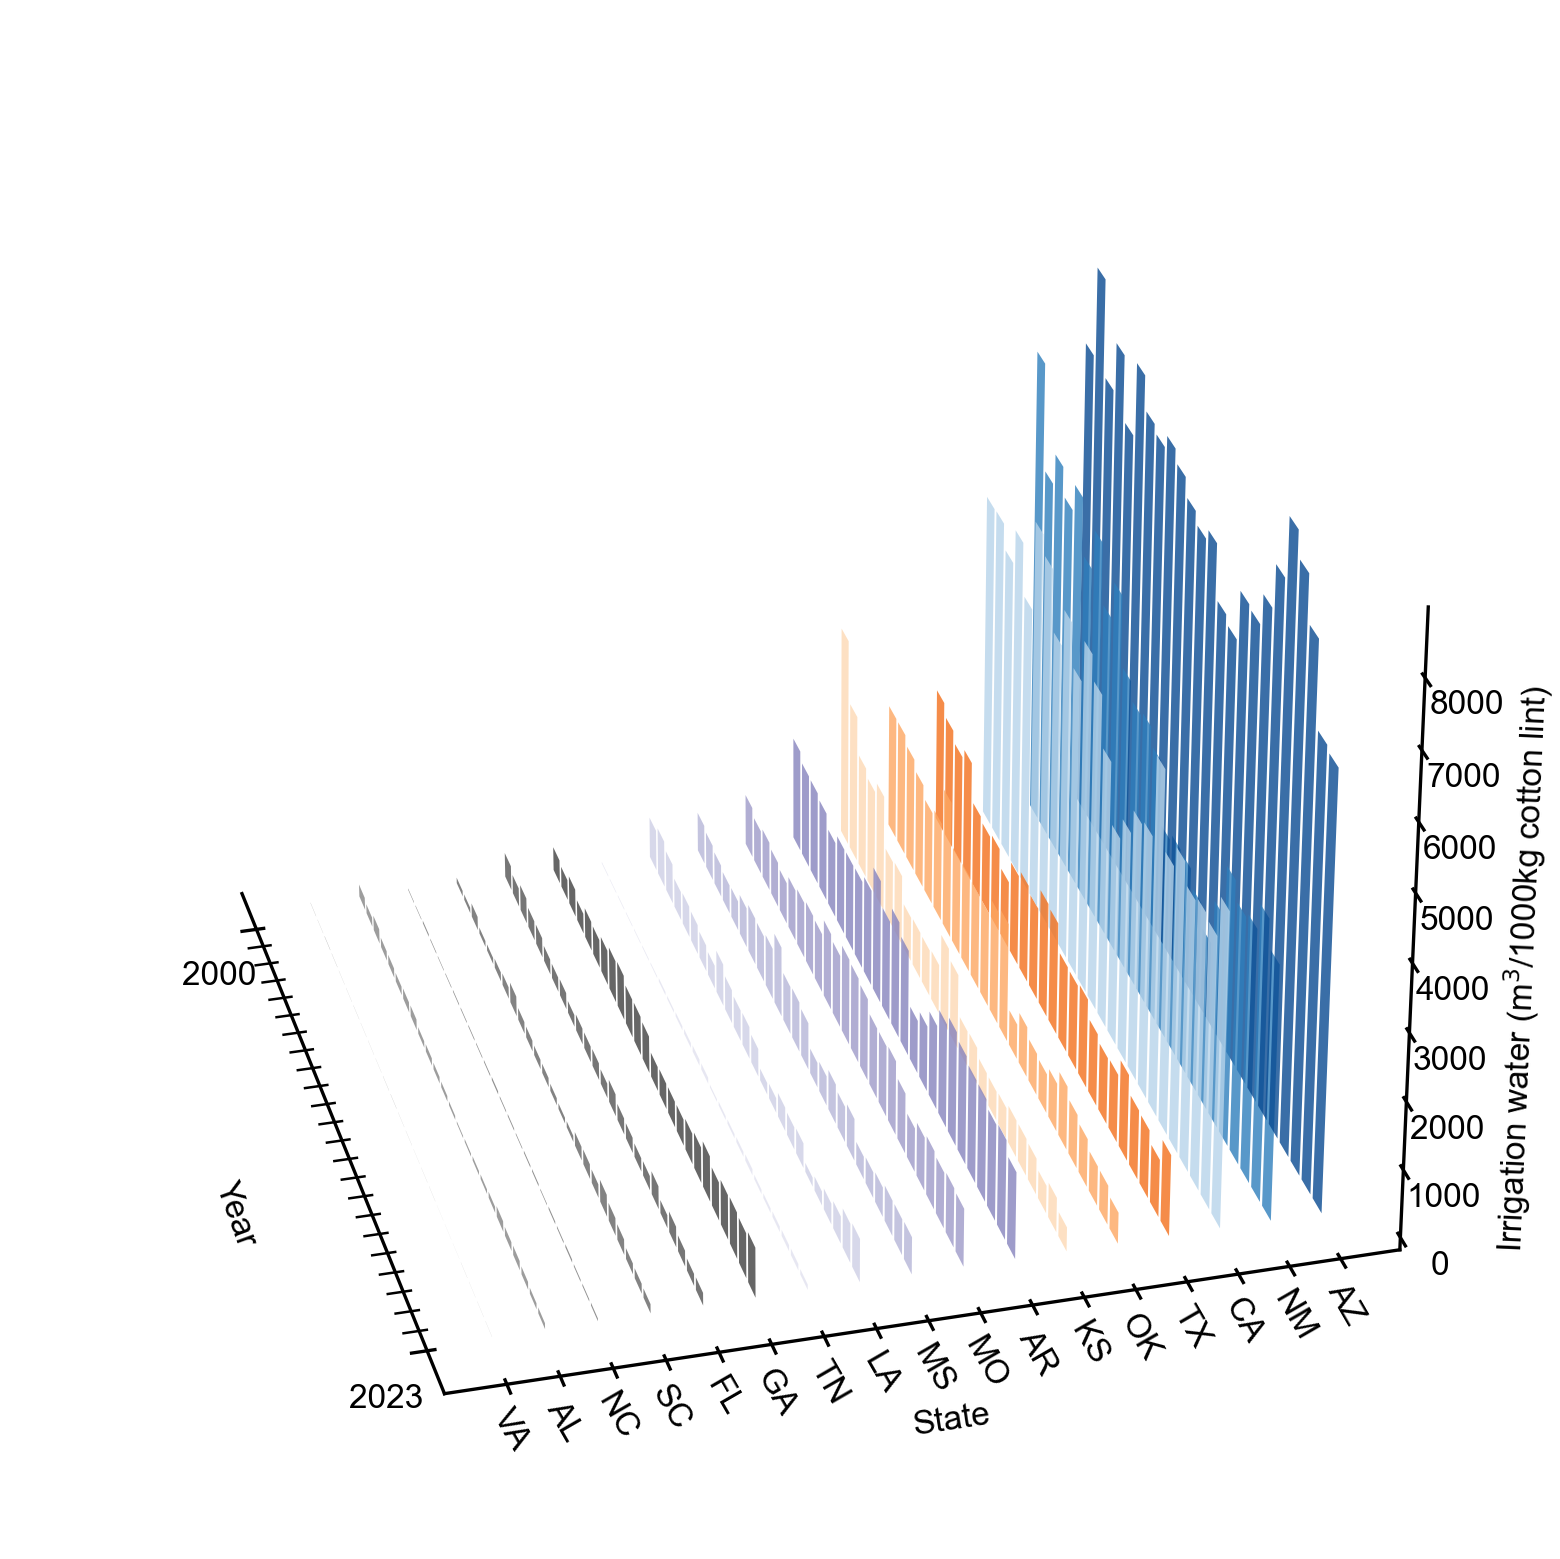

In [8]:
# 0.824 is the allocation parameter, calculate the unit water consumption m3/1000kg cotton lint
unit_water_consumption=total_water_consumption_in_m3*0.824/production_in_kg*1000

df=unit_water_consumption
print(df)
df.to_excel('../results/processed_data and results/water consumption.xlsx')
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

matplotlib.rcParams['font.family'] = "sans-serif"
plt.rcParams['font.sans-serif'] = "Arial"

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] =8

new_order = ['VA','AL', 'NC', 'SC', 'FL', 'GA', 'TN', 'LA', 'MS', 'MO', 'AR', 'KS', 'OK', 'TX', 'CA', 'NM', 'AZ']  # Specify the index names in the desired order
new_order = [
    'VIRGINIA','ALABAMA', 'NORTH CAROLINA', 'SOUTH CAROLINA',
    'FLORIDA',  'GEORGIA', 'TENNESSEE', 'LOUISIANA',
    'MISSISSIPPI', 'MISSOURI',  'ARKANSAS',  'KANSAS',
    'OKLAHOMA',  'TEXAS', 'CALIFORNIA',  'NEW MEXICO',  'ARIZONA']

df = df.reindex(new_order)

num_blues = 6
num_reds = 5
num_yellows = 3
num_browns = 3

blues = plt.cm.Greys(np.linspace(0.5, 0.8, num_blues))  # Vary alpha value for different shades of blue
reds = plt.cm.Purples(np.linspace(0.2, 0.6, num_reds))
yellows = plt.cm.Oranges(np.linspace(0.2, 0.6, num_yellows))
browns = plt.cm.Blues([0.3, 0.7, 0.9])

colors = np.concatenate((blues, reds, yellows, browns))

categories = ['VA','AL', 'NC', 'SC', 'FL', 'GA', 'TN', 'LA', 'MS', 'MO', 'AR', 'KS', 'OK', 'TX', 'CA', 'NM', 'AZ']

years = df.columns[0:]
x_pos = np.arange(len(categories))

fig = plt.figure(figsize=(7.2, 5))
ax = fig.add_subplot(111, projection='3d')
plt.subplots_adjust(left=0, right=0.9, top=1, bottom=0)
ax.grid(False)
ax.set_facecolor('white')

ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
yticks = np.arange(len(categories))
xticks = np.arange(len(years))


for i, category in enumerate(categories):
    xs = np.arange(len(years))
    ys = df.iloc[i, 0:].values

    cs = [colors[i % len(colors)]] * len(xs)
    # Optionally color the first bar of each set differently (here, using the same color for simplicity)
    cs[0] = cs[0]  # This could be set to a different color if desired

    ax.bar(xs, ys, zs=yticks[i], zdir='y', color=cs, alpha=0.8)



ax.set_xlabel('Year', rotation=-70, labelpad=0)
ax.set_ylabel('State', labelpad=-5)
ax.set_zlabel('Irrigation water (m$^3$/1000kg cotton lint)', labelpad=-5)


major_ticks = range(0, 24, 23)
ax.set_xticks(major_ticks)
ax.set_xticklabels([str(year+2000) for year in major_ticks], rotation=0)

# Set the minor ticks to every year including those that are not multiples of 5
minor_ticks = range(0, 24)
ax.set_xticks(minor_ticks, minor=True)
ax.tick_params(axis='x', which='minor', length=2)  # Make minor ticks smaller
ax.tick_params(axis='x', which='major', length=8)  # Make major ticks larger

ax.set_yticks(yticks)
ax.set_yticklabels(categories, rotation=-60)
ax.tick_params(axis='x', pad=0)
ax.tick_params(axis='y', pad=-5)
ax.tick_params(axis='z', pad=-2)

ax.view_init(elev=30, azim=-15)
plt.tight_layout()
plt.savefig('../outputs/water/figure_unit_water_consumption.tiff',dpi=300, bbox_inches='tight')
plt.savefig('../outputs/water/fig1_historywater.eps',format='eps')
plt.show()

2000    1853.181355
2001    1596.030937
2002    1634.189531
2003    1510.225051
2004    1367.249686
2005    1327.999080
2006    1300.773812
2007    1297.340748
2008    1414.761542
2009    1433.794234
2010    1398.765468
2011    1585.035214
2012    1358.692156
2013    1090.963036
2014    1042.019891
2015    1139.378042
2016    1092.362063
2017    1118.108695
2018    1097.238793
2019    1096.024428
2020    1068.022877
2021     994.640806
2022     897.099206
2023     967.590952
dtype: float64


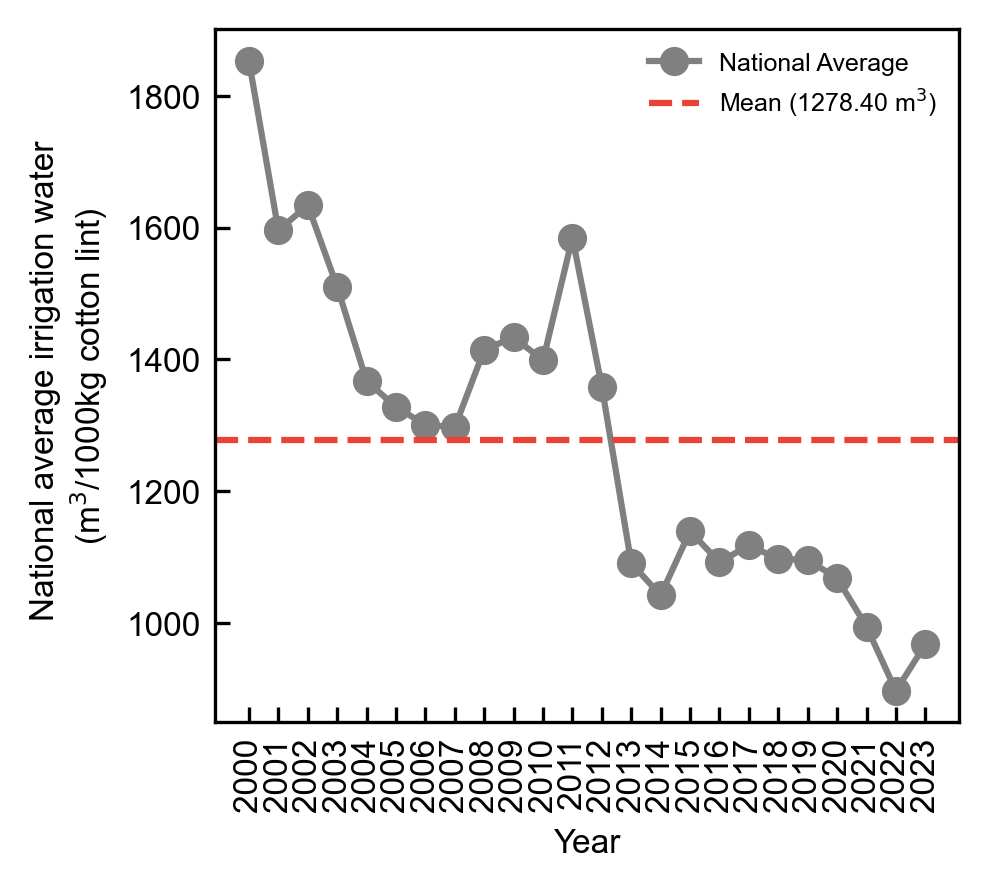

In [9]:
average_water_applied=total_water_consumption_in_m3.sum(axis=0)/(production_in_kg.sum(axis=0))*1000*0.824

plt.figure(figsize=(3.2, 3))
plt.plot(range(len(average_water_applied.index)), average_water_applied, 'o-', color='grey', label='National Average')
plt.axhline(y=average_water_applied.mean(), color='#EA4335', linestyle='--', label=f'Mean ({average_water_applied.mean():.2f} m$^3$)')


plt.xticks(range(len(average_water_applied.index)), average_water_applied.index, rotation=90)
plt.legend(loc='upper right', frameon=False, fontsize=6)
print(average_water_applied)
plt.xlabel('Year')
plt.ylabel('National average irrigation water \n(m$^3$/1000kg cotton lint)')
plt.savefig('../outputs/water/figure_water_overall_average.tiff',dpi=300, bbox_inches='tight')